# Phase 2 — Decomposing the LLM ranker into axioms and a residual

**The question (RQ3).** A generative LLM, used as a *pairwise ranker*, looks at two
documents and says which better answers a query. We have ~4,300 such cached verdicts on the
DL19 + DL20 top‑10 pool. Classical *retrieval axioms* also vote on each pair (e.g. "prefer
the document with more query‑term occurrences"). RQ3 asks:

> **How much of the LLM's verdicts can a combined axiom model reproduce, and what is the
> nature of the part it cannot — the _residual_?**

The residual is the raw material for the next question (RQ4), which tries to turn it into
new axioms. This notebook (1) fits the combined axiom model and measures the explained part,
(2) tests whether the leftover residual is *systematic* or just LLM noise, and (3) runs a
validity check carried over from Phase 1.

Everything reads the cached `results/rq3_decomposition/` artefacts — no model calls;
regenerate with `scripts/run_phase2.sh`. Full write‑up: `docs/phase2-design.md` §7. Two
models: **Qwen 3.6 35B** (primary) and **Flan‑T5‑large** (replication).

In [1]:
import json

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

from axiomrank.paths import results_dir

# Shared palette (matches the Phase 1 notebook).
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
PRIMARY, CONTRAST = "models/qwen3.6-35B-A3B-AWQ", "google/flan-t5-large"
MODELS = [PRIMARY, CONTRAST]
MODEL_DIR = {PRIMARY: "models__qwen3.6-35B-A3B-AWQ", CONTRAST: "google__flan-t5-large"}
MODEL_COLOR = {PRIMARY: "#2a78d6", CONTRAST: "#1baf7a"}
MODEL_LABEL = {PRIMARY: "Qwen 3.6 35B", CONTRAST: "Flan-T5-large"}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": INK2,
    "axes.edgecolor": BASE, "font.size": 11, "axes.titlesize": 12,
})

CELL = results_dir("rq3_decomposition") / "pooled_top10" / "metrics"


def load(model, filename):
    path = CELL / MODEL_DIR[model] / filename
    return pd.read_csv(path) if filename.endswith(".csv") else json.loads(path.read_text())


## 1. The decomposition — how much do the axioms explain?

**Method.** We predict the LLM's decisive verdict (which document it preferred) from *all*
axiom votes at once, with an L2‑regularised logistic regression under **query‑grouped
5‑fold cross‑validation** — so every number below is measured on queries the model never saw
while fitting. We read it against two reference points:

* **Base rate** — accuracy of blindly always guessing the majority class. The floor.
* **Reliability ceiling** — the LLM is not deterministic: swap the two documents' presentation
  order and it sometimes flips. That noise caps how well *any* predictor can do. We estimate
  the ceiling from the order‑swap agreement rate. The gap between the axiom model and the
  ceiling is **reducible** residual (structure a better model could still capture); the gap
  *above* the ceiling is irreducible LLM noise.

**Two ways to read "explained":**

* **CV accuracy** — fraction of verdicts predicted correctly out‑of‑fold. Intuitive, but a
  pair called right at p = 0.51 counts the same as one called at p = 0.99.
* **McFadden pseudo‑R²** — the fraction of the LLM's *label uncertainty* (its entropy) that
  the axiom model removes, versus a base‑rate null. **0** = no better than guessing the class
  prior; **1** = predicts the LLM perfectly. It rewards confident‑correct and penalises
  confident‑wrong predictions, so unlike accuracy it does not hinge on the 0.5 threshold. A
  low pseudo‑R² is the headline number: *the axioms account for very little of the LLM's
  decisions.*

**How to read the figure.** Each row is one model; the line runs base rate (grey) →
combined axiom model (colour) → reliability ceiling (open). A short coloured segment means a
thin explained part; a long colour→open segment means a lot of reducible residual is still
on the table.

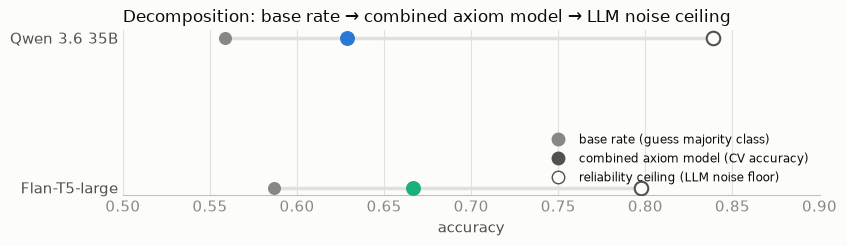

,n,base,cv_acc,gain,auc,pseudo_r2,ceiling,reducible,nl_headroom,sem_dcv
model,,,,,,,,,,
Qwen 3.6 35B,3158,0.5589,0.6286,0.0697,0.6587,0.0565,0.8386,0.2101,0.0130,-0.0051
Flan-T5-large,2931,0.5868,0.6663,0.0795,0.6863,0.0740,0.7974,0.1311,0.0024,-0.0143


In [2]:
rows = []
for m in MODELS:
    d = load(m, "decomposition.json"); lex, sem = d["lexical"], d["lexical_semantic"]
    rows.append({
        "model": m, "n": lex["n_decisive_pairs"], "base": lex["base_rate"],
        "cv_acc": lex["cv_accuracy"], "gain": lex["accuracy_gain_over_base"],
        "auc": lex["cv_auc"], "pseudo_r2": lex["information"]["pseudo_r2"],
        "ceiling": lex["reliability_ceiling"], "reducible": lex["reducible_residual_upper"],
        "nl_headroom": lex["nonlinear_headroom"], "sem_dcv": sem["cv_accuracy"] - lex["cv_accuracy"],
    })
dec = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8.6, 2.6))
for y, r in enumerate(dec.itertuples()):
    ax.plot([r.base, r.ceiling], [y, y], color=GRID, linewidth=2.5, zorder=1)
    ax.scatter(r.base, y, s=70, color=MUTED, zorder=2)
    ax.scatter(r.cv_acc, y, s=95, color=MODEL_COLOR[r.model], zorder=3)
    ax.scatter(r.ceiling, y, s=95, facecolor=SURFACE, edgecolor=INK2, linewidth=1.5, zorder=3)
ax.set_yticks(range(len(dec)), [MODEL_LABEL[r.model] for r in dec.itertuples()])
ax.invert_yaxis(); ax.set_xlim(0.50, 0.90)
ax.set_xlabel("accuracy")
ax.set_title("Decomposition: base rate → combined axiom model → LLM noise ceiling", loc="left")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.xaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True); ax.tick_params(length=0)
legend = [
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=MUTED, markeredgecolor=MUTED,
           markersize=9, label="base rate (guess majority class)"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=INK2, markeredgecolor=INK2,
           markersize=9, label="combined axiom model (CV accuracy)"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=SURFACE, markeredgecolor=INK2,
           markersize=9, label="reliability ceiling (LLM noise floor)"),
]
ax.legend(handles=legend, loc="lower right", frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

dec.assign(model=lambda x: x.model.map(MODEL_LABEL)).set_index("model").round(4)


**Reading it.** The combined model beats the base rate by only ~0.07, and pseudo‑R² is
just **0.057 (Qwen) / 0.074 (Flan)**: the axioms remove only 6–7 % of the LLM's decision
uncertainty — **the residual is over 93 % of the behaviour.** The gradient‑boosted variant
(`nl_headroom`) adds almost nothing, so this thin explained part is not the linear model
missing interactions — it is genuinely how little the axioms track the LLM here. Adding
WordNet semantics (`sem_dcv` < 0) *lowers* accuracy, so the Phase 1 RQ2 null carries into the
pool. But the colour→open gap is real (**~0.21 reducible** for Qwen): much of the residual
lies *below* the noise ceiling, so it is reducible structure, not just noise — which is what
makes RQ4 worth doing. The per‑collection fits confirm it replicates:

In [3]:
rows = []
for m in MODELS:
    for c in ["dl19_top10", "dl20_top10"]:
        cd = load(m, f"by_collection/{c}/decomposition.json")["lexical"]
        rows.append({"model": MODEL_LABEL[m], "cell": c, "base": round(cd["base_rate"], 3),
                     "cv_acc": round(cd["cv_accuracy"], 3),
                     "gain": round(cd["accuracy_gain_over_base"], 3)})
pd.DataFrame(rows).set_index(["model", "cell"])


base  cv_acc   gain
model         cell                            
Qwen 3.6 35B  dl19_top10  0.573   0.641  0.068
              dl20_top10  0.548   0.592  0.044
Flan-T5-large dl19_top10  0.600   0.669  0.068
              dl20_top10  0.576   0.641  0.065

## 2. Is the residual *systematic*? — the question that decides RQ4

A large residual only helps RQ4 if it has **structure** — recurring patterns a new axiom
could capture — rather than being the LLM's random noise. We test this directly.

**The residual model.** For each pair we take *non‑axiom* covariates — signed *doc₁ − doc₂*
differences the axiom battery does **not** encode:

| covariate | meaning |
|---|---|
| `d_len`  | difference in document length (verbosity) |
| `d_qcov` | difference in query‑term coverage |
| `d_rank`, `d_score` | difference in BM25 rank / score (first‑stage strength) |

We ask whether these covariates can predict the LLM's verdict **on top of what the axioms
already say** (we condition on the axiom model's own prediction). That improvement is the
**lift**. If the lift's 95 % query‑bootstrap CI is entirely above zero, the covariates carry
real structure the axioms miss — a *systematic* residual.

We report two covariate sets: **`content`** (`d_len`, `d_qcov` — text properties, the
candidates for a new *content* axiom) and **`all`** (adds rank/score strength). The
pre‑registered decision (design §6.1) reads the **content** lift specifically: first‑stage
strength and the LLM's own confidence are not admissible axiom seeds.

**How to read the figure.** Each row is one *model × covariate set*. The bar is the 95 % CI,
the marker is the lift. A **filled** marker with its whole bar right of the dotted zero line
= systematic; an **open** marker straddling zero = not distinguishable from noise.

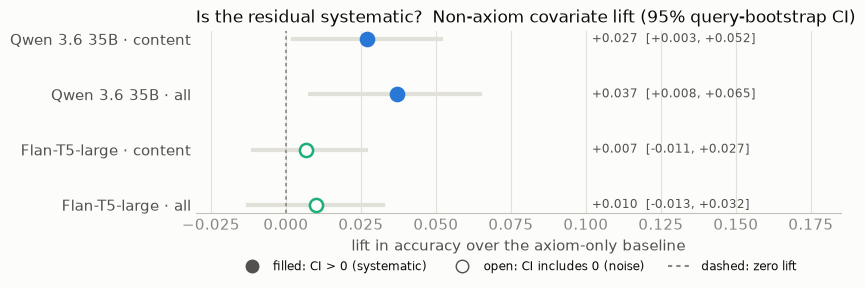

In [4]:
fig, ax = plt.subplots(figsize=(8.6, 3.2))
labels, y = [], 0
for m in MODELS:
    r = load(m, "residual_model.json")
    for setname, key in [("content", "content_only"), ("all", "all_covariates")]:
        v = r[key]; above = v["lift_ci_lo"] > 0
        ax.plot([v["lift_ci_lo"], v["lift_ci_hi"]], [y, y], color=GRID, linewidth=3, zorder=1)
        ax.scatter(v["lift"], y, s=90, zorder=3, color=MODEL_COLOR[m],
                   facecolor=MODEL_COLOR[m] if above else SURFACE,
                   edgecolor=MODEL_COLOR[m], linewidth=1.8)
        ax.text(0.102, y, f'{v["lift"]:+.3f}  [{v["lift_ci_lo"]:+.3f}, {v["lift_ci_hi"]:+.3f}]',
                va="center", ha="left", fontsize=8.5, color=INK2)
        labels.append(f"{MODEL_LABEL[m]} · {setname}"); y += 1
ax.axvline(0, color=MUTED, linewidth=1.2, linestyle=(0, (2, 2)), zorder=2)
ax.set_yticks(range(len(labels)), labels); ax.invert_yaxis(); ax.set_xlim(-0.03, 0.185)
ax.set_xlabel("lift in accuracy over the axiom-only baseline")
ax.set_title("Is the residual systematic?  Non-axiom covariate lift (95% query-bootstrap CI)", loc="left")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.xaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True); ax.tick_params(length=0)
legend = [
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=INK2, markeredgecolor=INK2,
           markersize=9, label="filled: CI > 0 (systematic)"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=SURFACE, markeredgecolor=INK2,
           markersize=9, label="open: CI includes 0 (noise)"),
    Line2D([0], [0], color=MUTED, linestyle=(0, (2, 2)), label="dashed: zero lift"),
]
ax.legend(handles=legend, loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=3,
          frameon=False, fontsize=8.5)
fig.subplots_adjust(left=0.22, right=0.97, bottom=0.28, top=0.85); plt.show()


**Reading it.** Qwen's content lift is small but real — **+0.027, CI [+0.003, +0.052]**,
wholly above zero — and (§7) it replicates across collections (DL20 +0.039). Flan's CI
straddles zero, so the lift *magnitude* is model‑specific. But the residual **clusters**
below show the *shape* is shared across both models.

**What kind of structure?** We cluster the residual pairs (the ones the axioms get wrong) by
their covariates and read each cluster's centroid. Both models yield the same two telling
clusters: a **high‑verbosity** one, where the LLM's residual choice tracks the much longer
document (large `d_len`), and a **high‑coverage** one, tracking broader query‑term coverage
(large `d_qcov`). These two axes are the seed hypotheses for RQ4.

**How to read the figure.** Each bubble is a residual cluster, placed at its mean length
difference (x) and query‑coverage difference (y); bubble area ∝ number of pairs. A bubble far
from the origin marks a recurring, content‑shaped mistake — up/right = the LLM residually
prefers the longer / better‑covering document.

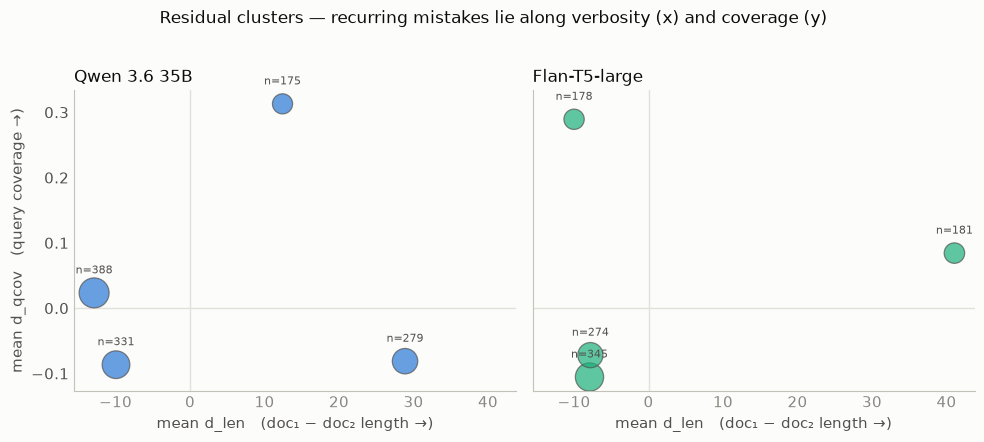

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3), sharex=True, sharey=True)
for ax, m in zip(axes, MODELS):
    cl = load(m, "residual_clusters.csv")
    ax.axhline(0, color=GRID, lw=1, zorder=1); ax.axvline(0, color=GRID, lw=1, zorder=1)
    ax.scatter(cl["mean_d_len"], cl["mean_d_qcov"], s=cl["size"] * 1.2, zorder=3,
               color=MODEL_COLOR[m], alpha=0.7, edgecolor=INK2, linewidth=0.9)
    for r in cl.itertuples():
        ax.annotate(f"n={r.size}", (r.mean_d_len, r.mean_d_qcov), textcoords="offset points",
                    xytext=(0, 14), ha="center", fontsize=8, color=INK2)
    ax.set_title(MODEL_LABEL[m], loc="left")
    ax.set_xlabel("mean d_len   (doc₁ − doc₂ length →)")
    ax.spines[["top", "right"]].set_visible(False); ax.tick_params(length=0)
axes[0].set_ylabel("mean d_qcov   (query coverage →)")
fig.suptitle("Residual clusters — recurring mistakes lie along verbosity (x) and coverage (y)",
             x=0.5, y=1.02, fontsize=12.5)
plt.tight_layout(); plt.show()


## 3. Validity check — the gap gradient (carried over from Phase 1)

**Why this check exists.** The whole thesis rests on the top‑10 residual being *real* — a
property of LLM reranking — not a bug in our pipeline. The standard sanity signature: axioms
should **work on easy pairs and fail on hard ones**. "Easy" = a large BM25 *rank gap* (one
document is a far stronger first‑stage match); "hard" = a small gap (both similar), which is
exactly the top‑10 setting. So axiom agreement should *rise* with the rank gap. Phase 1 saw
this only *partially* per‑axiom; here we test it for the whole combined model.

**BM25 as the yardstick.** We also plot **BM25 used directly as a pairwise predictor** — it
"prefers" the better first‑stage-ranked document — scored against the LLM on the *same*
decisive pairs. This is the natural baseline (it was the Phase 1 effectiveness gate) and,
crucially, a **positive control**: BM25 is the very signal the rank gap is built from, so if
the pipeline can express the easy‑vs‑hard signature *at all*, BM25's line must show it. It
tells us whether a flat axiom line is a broken pipeline or a real property of the axioms.

**How to read the figure.**

* **Left — top‑10 pairs (gaps 1–9).** **Solid + round** = the combined axiom model's
  accuracy; **dash‑dot + square** (same colour) = **BM25‑as‑predictor** accuracy; **dashed**
  = the LLM's *decisive rate* (how often it gives a firm, order‑consistent verdict at all);
  grey **dotted** = chance (0.5).
* **Right — the wide‑gap `uniform50` control (full rank‑gap range).** Solid+round = the
  combined model's accuracy and dash‑dot+square = BM25, over gaps far wider than the top‑10
  ever reaches.

If the pipeline signature held, the right panel's lines would climb steeply toward the
ceiling — watch which one actually does.

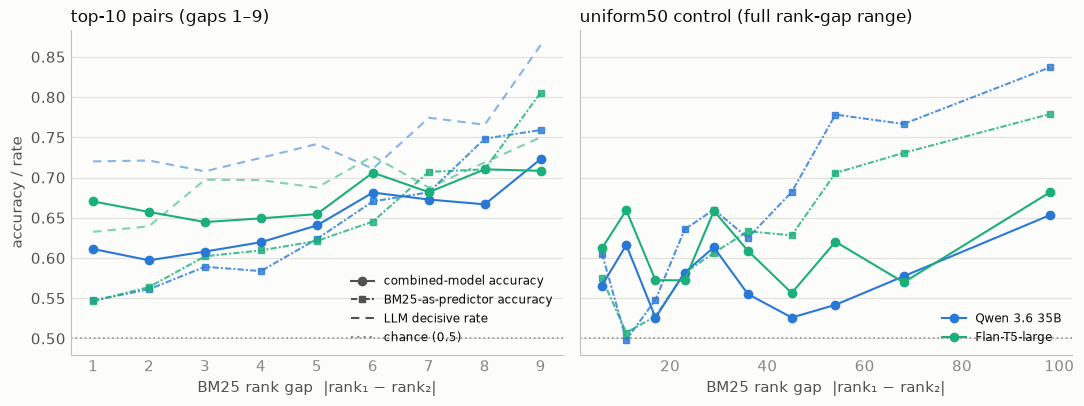

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for m in MODELS:
    g = load(m, "gap_gradient.csv").drop_duplicates("gap_bin").sort_values("gap_bin")
    ax[0].plot(g["gap_bin"], g["joint_cv_accuracy"], marker="o", color=MODEL_COLOR[m], zorder=3)
    ax[0].plot(g["gap_bin"], g["bm25_accuracy"], marker="s", markersize=4,
               linestyle=(0, (3, 1, 1, 1)), color=MODEL_COLOR[m], alpha=0.8, zorder=2)
    ax[0].plot(g["gap_bin"], g["decisive_rate"], linestyle=(0, (4, 3)), color=MODEL_COLOR[m],
               alpha=0.55, zorder=2)
    u = load(m, "gap_gradient_uniform.csv").drop_duplicates("gap_bin").sort_values("gap_bin")
    ax[1].plot(u["gap_bin"], u["joint_cv_accuracy"], marker="o", color=MODEL_COLOR[m], zorder=3)
    ax[1].plot(u["gap_bin"], u["bm25_accuracy"], marker="s", markersize=4,
               linestyle=(0, (3, 1, 1, 1)), color=MODEL_COLOR[m], alpha=0.8, zorder=2)
for a in ax:
    a.axhline(0.5, color=MUTED, lw=1.1, linestyle=(0, (1, 2)), zorder=1)
    a.set_xlabel("BM25 rank gap  |rank₁ − rank₂|")
    a.spines[["top", "right"]].set_visible(False)
    a.yaxis.grid(True, color=GRID, lw=0.8); a.set_axisbelow(True); a.tick_params(length=0)
ax[0].set_title("top-10 pairs (gaps 1–9)", loc="left")
ax[1].set_title("uniform50 control (full rank-gap range)", loc="left")
ax[0].set_ylabel("accuracy / rate")

style_legend = [
    Line2D([0], [0], color=INK2, marker="o", label="combined-model accuracy"),
    Line2D([0], [0], color=INK2, marker="s", markersize=5, linestyle=(0, (3, 1, 1, 1)),
           label="BM25-as-predictor accuracy"),
    Line2D([0], [0], color=INK2, linestyle=(0, (4, 3)), label="LLM decisive rate"),
    Line2D([0], [0], color=MUTED, linestyle=(0, (1, 2)), label="chance (0.5)"),
]
color_legend = [Line2D([0], [0], color=MODEL_COLOR[m], marker="o", label=MODEL_LABEL[m])
                for m in MODELS]
ax[0].legend(handles=style_legend, loc="lower right", frameon=False, fontsize=8.5)
ax[1].legend(handles=color_legend, loc="lower right", frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

**Reading it.** Within top‑10, the combined model's accuracy drifts up with the gap — but
the LLM's decisive rate climbs in lockstep, so that "gradient" is mostly the *LLM becoming
more self‑consistent* on wider gaps, not the axioms tracking it better. **BM25 tells the
opposite story:** its accuracy climbs sharply with the gap (≈0.55 → 0.76 for Qwen, 0.55 →
0.81 for Flan) and *overtakes the whole axiom battery* by the widest top‑10 gaps — the single
first‑stage score already out‑predicts the axioms exactly where the pairs are easy.

The `uniform50` control makes it unmistakable. There BM25 rises steeply to **~0.84 (Qwen) /
~0.78 (Flan)** as the gap widens, tracing the textbook easy‑vs‑hard signature — while the
combined axiom model stays essentially **flat (~0.55)** across the entire range. So the
signature the pipeline is *supposed* to show is present and strong (BM25 exhibits it); the
axiom model simply does not, at any gap.

**Conclusion:** the top‑10 null is **validated** — and now more sharply. BM25 is the positive
control that clears the pipeline: the easy‑vs‑hard gradient is real and measurable here. The
axioms' failure to show it is therefore a genuine property of the axioms, not a sampling or
plumbing artefact, so the large residual is a real object. (That BM25 itself climbs while the
axioms don't is not a route to explaining the LLM: first‑stage rank strength is excluded from
the admissible axiom seeds by design §3.4 — it is a difficulty proxy, not a content axiom.)

## Summary — RQ4 is the main act

Putting the three pieces together:

1. **§1 — thin explained part.** The combined axiom model removes only ~6–7 % of the LLM's
   decision uncertainty; the residual is >93 % of the behaviour, with ~0.21 of *reducible*
   headroom below the noise floor.
2. **§2 — the residual is partly systematic.** Non‑axiom content covariates lift prediction
   above the axioms (Qwen, CI above zero; replicating across collections), and the residual
   clusters name the same two dimensions in both models: **verbosity/length** and
   **query‑coverage**.
3. **§3 — and it is real,** not a pipeline artefact.

This is the "rich residual" branch of the pre‑registered decision (design §6.1): **RQ4
proceeds as the primary contribution**, formalising two new‑axiom hypotheses — a
length/verbosity constraint and a query‑coverage constraint. Full numbers, CIs and caveats:
`docs/phase2-design.md` §7.